In [67]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
start = "2010-01-01"
end = "2025-12-31"

vix = yf.download("^VIX", start=start, end=end)
gold = yf.download("GC=F", start=start, end=end)
spy = yf.download("SPY", start=start, end=end)

vix = vix["Adj Close"] if "Adj Close" in vix.columns else vix["Close"]
gold = gold["Adj Close"] if "Adj Close" in gold.columns else gold["Close"]
spy = spy["Adj Close"] if "Adj Close" in spy.columns else spy["Close"]

df = pd.concat([vix, gold, spy], axis=1)
df.columns = ["VIX", "Gold", "SPY"]

df["VIX_Return"] = df["VIX"].pct_change()
df["Gold_Return"] = df["Gold"].pct_change()
df["SPY_Return"] = df["SPY"].pct_change()

df = df.dropna()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
C:\Users\kiera\AppData\Local\Temp\ipykernel_12156\2088840.py:19: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["VIX_Return"] = df["VIX"].pct_change()
C:\Users\kiera\AppData\Local\Temp\ipykernel_12156\2088840.py:20: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["Gold_Return"] = df["Gold"].pct_change()
C:\Users\kiera\AppData\Local\Temp\ipykernel_12156\2088840.py:21: FutureWarning: The def

In [68]:
def run_strategy(df, threshold=0.25, holding_period=10):
    df = df.copy()
    
    df["Signal"] = df["VIX_Return"] > threshold
    df["Position"] = 0

    for i in range(len(df)):
        if df["Signal"].iloc[i]:
            start_idx = i + 1
            end_idx = min(i + 1 + holding_period, len(df))
            df.iloc[start_idx:end_idx, df.columns.get_loc("Position")] = 1

    df["Strategy_Return"] = np.where(
        df["Position"] == 1,
        df["Gold_Return"],
        df["SPY_Return"]
    )

    df["Strategy_Cum"] = (1 + df["Strategy_Return"]).cumprod()

    return df

In [69]:
result = run_strategy(df, threshold=0.25, holding_period=10)

In [70]:
thresholds = [0.2, 0.25, 0.3, 0.35]
holding_periods = [5, 10, 15]

results = []

for t in thresholds:
    for h in holding_periods:
        temp = run_strategy(df, threshold=t, holding_period=h)
        
        ann_return = (temp["Strategy_Cum"].iloc[-1])**(252/len(temp)) - 1
        sharpe = np.sqrt(252) * temp["Strategy_Return"].mean() / temp["Strategy_Return"].std()
        
        results.append({
            "Threshold": t,
            "Holding": h,
            "Annual Return": ann_return,
            "Sharpe": sharpe
        })

results_df = pd.DataFrame(results)
results_df

,Threshold,Holding,Annual Return,Sharpe
0,0.20,5,0.149439,0.970678
1,0.20,10,0.145040,0.969715
2,0.20,15,0.139461,0.943976
3,0.25,5,0.152157,0.976157
4,0.25,10,0.174470,1.127105
5,0.25,15,0.153193,1.017416
6,0.30,5,0.138416,0.881630
7,0.30,10,0.158839,1.025681
8,0.30,15,0.149147,0.979490
9,0.35,5,0.145073,0.916848


In [71]:
def sharpe(x):
    return np.sqrt(252) * x.mean() / x.std()

print("Strategy Sharpe:", sharpe(result["Strategy_Return"]))
print("SPY Sharpe:", sharpe(result["SPY_Return"]))

Strategy Sharpe: 1.1271050480464917
SPY Sharpe: 0.8488402872142923


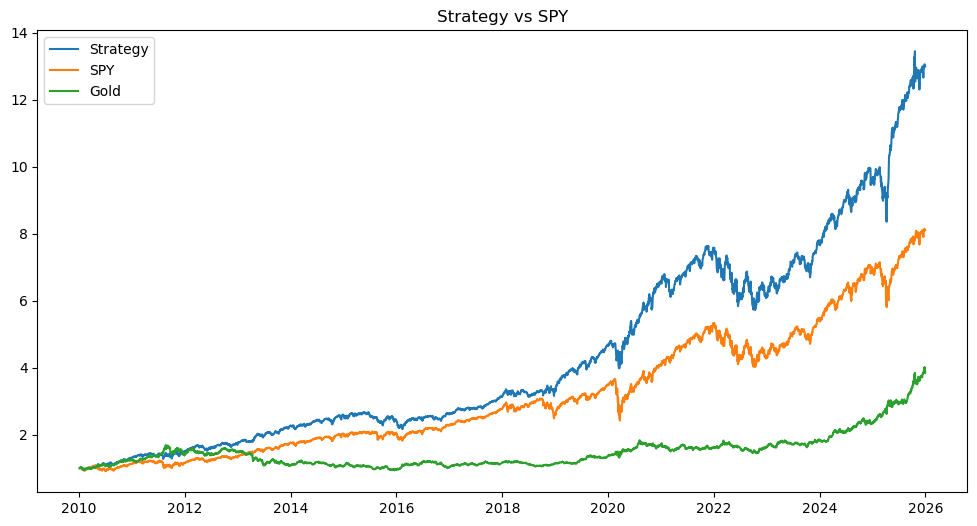

In [72]:
plt.figure(figsize=(12,6))
plt.plot(result.index, result["Strategy_Cum"], label="Strategy")
plt.plot(result.index, (1 + result["SPY_Return"]).cumprod(), label="SPY")
plt.plot(result.index, (1 + result["Gold_Return"]).cumprod(), label="Gold")
plt.legend()
plt.title("Strategy vs SPY")
plt.show()

In [73]:
# -----------------------------
# Recreate Feature DataFrame
# -----------------------------
df_features = df.copy()

df_features["VIX_Level"] = df_features["VIX"]
df_features["VIX_5d_Change"] = df_features["VIX"].pct_change(5)
df_features["VIX_Volatility"] = df_features["VIX_Return"].rolling(10).std()

df_features["SPY_Volatility"] = df_features["SPY_Return"].rolling(10).std()

df_features["Gold_Lag1"] = df_features["Gold_Return"].shift(1)

# Signal (use whichever threshold you're analyzing)
df_features["Signal"] = df_features["VIX_Return"] > 0.25

# Drop NaNs from rolling + lagging
df_features = df_features.dropna()

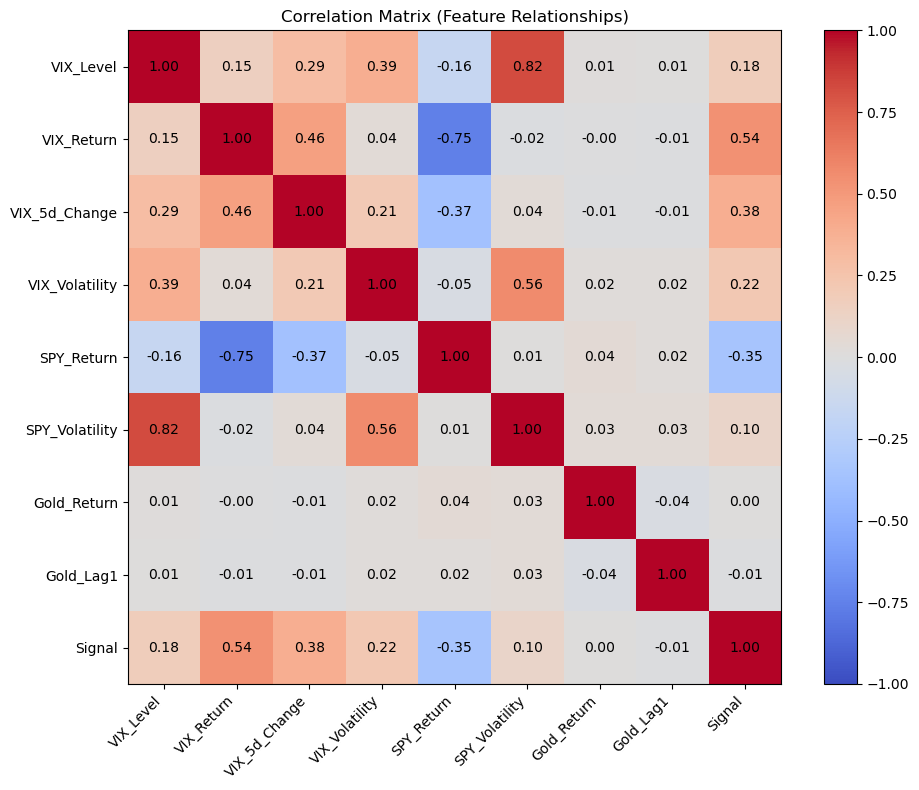

In [74]:
# -----------------------------
# Improved Correlation Heatmap
# -----------------------------
corr_matrix = df_features[[
    "VIX_Level",
    "VIX_Return",
    "VIX_5d_Change",
    "VIX_Volatility",
    "SPY_Return",
    "SPY_Volatility",
    "Gold_Return",
    "Gold_Lag1",
    "Signal"
]].corr()

fig, ax = plt.subplots(figsize=(10,8))

# Create heatmap
cax = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Add color bar
fig.colorbar(cax)

# Set ticks
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)

# Add numbers inside cells
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        value = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha='center', va='center', color='black')

# Title
plt.title("Correlation Matrix (Feature Relationships)")
plt.tight_layout()
plt.show()

In [75]:
# -----------------------------
# Randomization Test
# -----------------------------
import numpy as np

def randomization_test(df, num_simulations=100):
    actual = run_strategy(df)
    actual_return = actual["Strategy_Cum"].iloc[-1]

    random_returns = []

    signal_indices = np.where(df["VIX_Return"] > 0.25)[0]
    num_signals = len(signal_indices)

    for _ in range(num_simulations):
        random_df = df.copy()
        random_df["Signal"] = False
        
        # Randomly choose same number of signal days
        random_days = np.random.choice(len(df), size=num_signals, replace=False)
        random_df.loc[random_df.index[random_days], "Signal"] = True

        # Re-run strategy using randomized signals
        random_df["Position"] = 0
        
        for i in range(len(random_df)):
            if random_df["Signal"].iloc[i]:
                start = i + 1
                end = min(i + 11, len(random_df))
                random_df.iloc[start:end, random_df.columns.get_loc("Position")] = 1

        random_df["Strategy_Return"] = np.where(
            random_df["Position"] == 1,
            random_df["Gold_Return"],
            random_df["SPY_Return"]
        )

        random_df["Strategy_Cum"] = (1 + random_df["Strategy_Return"]).cumprod()
        random_returns.append(random_df["Strategy_Cum"].iloc[-1])

    print("Actual Final Return:", actual_return)
    print("Average Random Return:", np.mean(random_returns))
    print("Outperformance vs Random:", actual_return > np.mean(random_returns))

In [76]:
# -----------------------------
# Add Drawdown Feature
# -----------------------------
df["SPY_Drawdown_5d"] = df["SPY"].pct_change(5)

# Modify strategy
def run_strategy_drawdown(df, threshold=0.25, holding_period=10, drawdown_thresh=-0.03):
    df = df.copy()
    
    df["Signal"] = (df["VIX_Return"] > threshold) & (df["SPY_Drawdown_5d"] < drawdown_thresh)
    df["Position"] = 0

    for i in range(len(df)):
        if df["Signal"].iloc[i]:
            start = i + 1
            end = min(i + 1 + holding_period, len(df))
            df.iloc[start:end, df.columns.get_loc("Position")] = 1

    df["Strategy_Return"] = np.where(
        df["Position"] == 1,
        df["Gold_Return"],
        df["SPY_Return"]
    )

    df["Strategy_Cum"] = (1 + df["Strategy_Return"]).cumprod()
    return df

In [77]:
# -----------------------------
# Add Gold Momentum
# -----------------------------
df["Gold_Momentum_5d"] = df["Gold"].pct_change(5)

def run_strategy_momentum(df, threshold=0.25, holding_period=10):
    df = df.copy()
    
    df["Signal"] = (df["VIX_Return"] > threshold) & (df["Gold_Momentum_5d"] > 0)
    df["Position"] = 0

    for i in range(len(df)):
        if df["Signal"].iloc[i]:
            start = i + 1
            end = min(i + 1 + holding_period, len(df))
            df.iloc[start:end, df.columns.get_loc("Position")] = 1

    df["Strategy_Return"] = np.where(
        df["Position"] == 1,
        df["Gold_Return"],
        df["SPY_Return"]
    )

    df["Strategy_Cum"] = (1 + df["Strategy_Return"]).cumprod()
    return df

In [78]:
def run_strategy_with_exit(df, threshold=0.25, max_holding=10):
    df = df.copy()
    
    df["Signal"] = df["VIX_Return"] > threshold
    df["Position"] = 0

    i = 0
    while i < len(df):
        if df["Signal"].iloc[i]:
            holding = 0
            j = i + 1
            
            while j < len(df) and holding < max_holding:
                df.iloc[j, df.columns.get_loc("Position")] = 1
                holding += 1
                
                # Exit early if VIX drops (mean reversion)
                if df["VIX_Return"].iloc[j] < -0.1:
                    break
                
                j += 1
            
            i = j
        else:
            i += 1

    df["Strategy_Return"] = np.where(
        df["Position"] == 1,
        df["Gold_Return"],
        df["SPY_Return"]
    )

    df["Strategy_Cum"] = (1 + df["Strategy_Return"]).cumprod()
    return df

In [79]:
def run_hybrid_strategy(
    df,
    vix_threshold=0.25,
    drawdown_thresh=-0.03,
    gold_mom_thresh=0,
    max_holding=10,
    stop_loss=-0.02,
    take_profit=0.03,
    vix_exit_thresh=-0.1
):
    df = df.copy()

    # -----------------------------
    # Feature Engineering
    # -----------------------------
    df["SPY_Drawdown_5d"] = df["SPY"].pct_change(5)
    df["Gold_Momentum_5d"] = df["Gold"].pct_change(5)

    # Entry signal (ALL conditions)
    df["Signal"] = (
        (df["VIX_Return"] > vix_threshold) &
        (df["SPY_Drawdown_5d"] < drawdown_thresh) &
        (df["Gold_Momentum_5d"] > gold_mom_thresh)
    )

    df["Position"] = 0

    i = 0
    while i < len(df):

        if df["Signal"].iloc[i]:
            entry_price = df["Gold"].iloc[i+1] if i+1 < len(df) else None
            holding_days = 0
            j = i + 1

            while j < len(df) and holding_days < max_holding:
                df.iloc[j, df.columns.get_loc("Position")] = 1
                holding_days += 1

                # Compute return since entry
                if entry_price is not None:
                    pnl = (df["Gold"].iloc[j] - entry_price) / entry_price

                    # Stop-loss
                    if pnl < stop_loss:
                        break

                    # Take-profit
                    if pnl > take_profit:
                        break

                # VIX mean reversion exit
                if df["VIX_Return"].iloc[j] < vix_exit_thresh:
                    break

                j += 1

            # Skip ahead to avoid overlapping trades
            i = j
        else:
            i += 1

    # -----------------------------
    # Returns
    # -----------------------------
    df["Strategy_Return"] = np.where(
        df["Position"] == 1,
        df["Gold_Return"],
        df["SPY_Return"]
    )

    # Transaction cost (optional but recommended)
    cost_per_trade = 0.0005
    trades = df["Position"].diff().abs()
    df["Strategy_Return"] -= trades * cost_per_trade

    df["Strategy_Cum"] = (1 + df["Strategy_Return"]).cumprod()

    return df

In [80]:
hybrid = run_hybrid_strategy(df)

In [81]:
def compute_metrics(df):
    returns = df["Strategy_Return"].dropna()
    cum = df["Strategy_Cum"]

    total_return = cum.iloc[-1] - 1
    log_return = np.log(cum.iloc[-1])

    ann_return = (cum.iloc[-1])**(252/len(cum)) - 1
    vol = returns.std() * np.sqrt(252)

    sharpe = np.sqrt(252) * returns.mean() / returns.std()

    # Max Drawdown
    peak = cum.cummax()
    drawdown = (cum - peak) / peak
    max_dd = drawdown.min()

    hit_rate = (returns > 0).mean()

    trades = df["Position"].diff().abs().sum()

    return {
        "Total Return": total_return,
        "Annual Return": ann_return,
        "Volatility": vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd,
        "Hit Rate": hit_rate,
        "Trades": trades
    }

In [82]:
# Baseline
baseline = run_strategy(df)

# Variants
strategy_30 = run_strategy_30(df)
drawdown_model = run_strategy_drawdown(df)
momentum_model = run_strategy_momentum(df)
exit_model = run_strategy_with_exit(df)

# Hybrid
hybrid_model = run_hybrid_strategy(df)

In [83]:
results = {
    "Baseline": compute_metrics(baseline),
    "Drawdown Filter": compute_metrics(drawdown_model),
    "Momentum Filter": compute_metrics(momentum_model),
    "Exit Strategy": compute_metrics(exit_model),
    "Hybrid Model": compute_metrics(hybrid_model)
\
}

summary_df = pd.DataFrame(results).T
summary_df

,Total Return,Annual Return,Volatility,Sharpe,Max Drawdown,Hit Rate,Trades
Baseline,11.997789,0.174470,0.153138,1.127105,-0.249716,0.549888,72.0
Drawdown Filter,11.859330,0.173682,0.153797,1.118551,-0.244964,0.552127,30.0
Momentum Filter,13.942645,0.184784,0.156508,1.162008,-0.244964,0.554616,48.0
Exit Strategy,5.512511,0.124667,0.162412,0.805213,-0.420642,0.551381,92.0
Hybrid Model,7.172215,0.140790,0.169410,0.862809,-0.365730,0.553758,22.0


In [84]:
summary_df.style.format({
    "Total Return": "{:.2%}",
    "Annual Return": "{:.2%}",
    "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Max Drawdown": "{:.2%}",
    "Hit Rate": "{:.2%}",
    "Trades": "{:.0f}"
})

,Total Return,Annual Return,Volatility,Sharpe,Max Drawdown,Hit Rate,Trades
Baseline,1199.78%,17.45%,15.31%,1.13,-24.97%,54.99%,72
Drawdown Filter,1185.93%,17.37%,15.38%,1.12,-24.50%,55.21%,30
Momentum Filter,1394.26%,18.48%,15.65%,1.16,-24.50%,55.46%,48
Exit Strategy,551.25%,12.47%,16.24%,0.81,-42.06%,55.14%,92
Hybrid Model,717.22%,14.08%,16.94%,0.86,-36.57%,55.38%,22


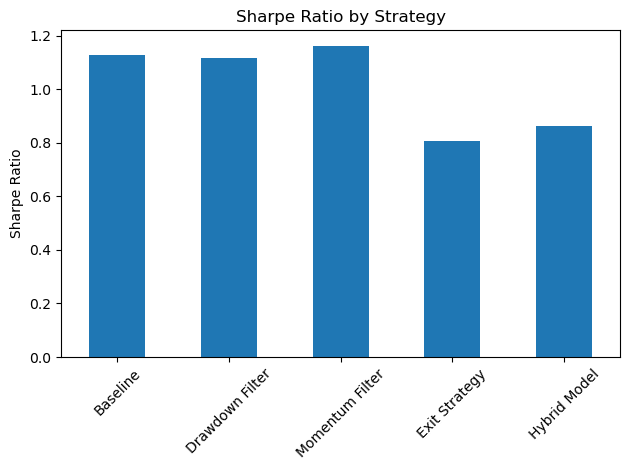

In [85]:
plt.figure()
summary_df["Sharpe"].plot(kind="bar")
plt.title("Sharpe Ratio by Strategy")
plt.ylabel("Sharpe Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

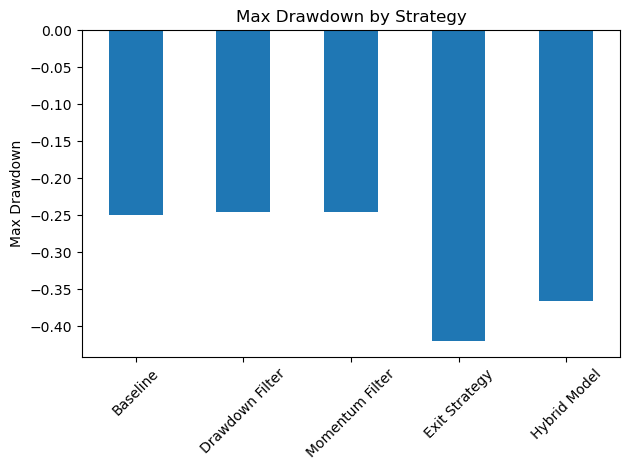

In [86]:
plt.figure()
summary_df["Max Drawdown"].plot(kind="bar")
plt.title("Max Drawdown by Strategy")
plt.ylabel("Max Drawdown")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [87]:
summary_df.sort_values(by="Sharpe", ascending=False)

,Total Return,Annual Return,Volatility,Sharpe,Max Drawdown,Hit Rate,Trades
Momentum Filter,13.942645,0.184784,0.156508,1.162008,-0.244964,0.554616,48.0
Baseline,11.997789,0.174470,0.153138,1.127105,-0.249716,0.549888,72.0
Drawdown Filter,11.859330,0.173682,0.153797,1.118551,-0.244964,0.552127,30.0
Hybrid Model,7.172215,0.140790,0.169410,0.862809,-0.365730,0.553758,22.0
Exit Strategy,5.512511,0.124667,0.162412,0.805213,-0.420642,0.551381,92.0


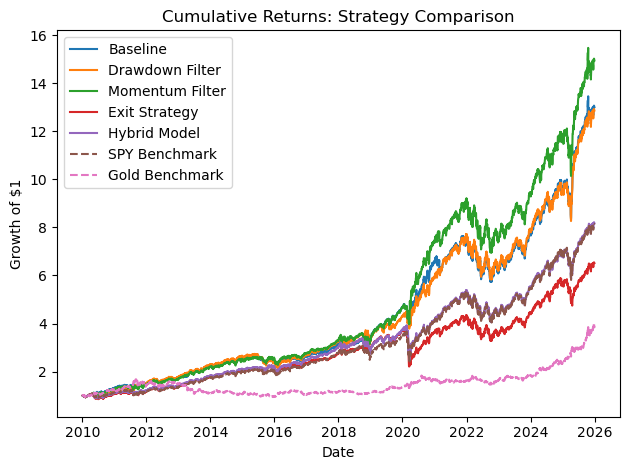

In [88]:
plt.figure()

# Plot each strategy
plt.plot(baseline["Strategy_Cum"], label="Baseline")
plt.plot(drawdown_model["Strategy_Cum"], label="Drawdown Filter")
plt.plot(momentum_model["Strategy_Cum"], label="Momentum Filter")
plt.plot(exit_model["Strategy_Cum"], label="Exit Strategy")
plt.plot(hybrid_model["Strategy_Cum"], label="Hybrid Model")

# Optional: Benchmarks
spy_cum = (1 + df["SPY_Return"].fillna(0)).cumprod()
gld_cum = (1 + df["Gold_Return"].fillna(0)).cumprod()
plt.plot(spy_cum, linestyle='--', label="SPY Benchmark")
plt.plot(gld_cum, linestyle='--', label="Gold Benchmark")

# Labels + formatting
plt.title("Cumulative Returns: Strategy Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.tight_layout()
plt.show()

In [89]:
# -----------------------------
# Event Study Setup
# -----------------------------
thresholds = [0.15, 0.20, 0.25, 0.30]
horizons = [10, 15, 20, 25]

results = []

for thresh in thresholds:
    for h in horizons:
        spy_returns = []
        gold_returns = []

        for i in range(len(df)):
            if df["VIX_Return"].iloc[i] > thresh:
                
                if i + h < len(df):
                    spy_ret = (df["SPY"].iloc[i + h] / df["SPY"].iloc[i]) - 1
                    gold_ret = (df["Gold"].iloc[i + h] / df["Gold"].iloc[i]) - 1
                    
                    spy_returns.append(spy_ret)
                    gold_returns.append(gold_ret)

        results.append({
            "Threshold": f"{int(thresh*100)}%",
            "Horizon": f"{h}d",
            "SPY": np.mean(spy_returns),
            "Gold": np.mean(gold_returns)
        })

event_df = pd.DataFrame(results)
event_df

,Threshold,Horizon,SPY,Gold
0,15%,10d,0.006149,0.006779
1,15%,15d,0.010312,0.008611
2,15%,20d,0.011459,0.012880
3,15%,25d,0.015152,0.011931
4,20%,10d,0.004077,0.006678
5,20%,15d,0.010935,0.006103
6,20%,20d,0.013857,0.013514
7,20%,25d,0.018828,0.011668
8,25%,10d,0.001946,0.013781
9,25%,15d,0.008940,0.008898


In [90]:
# Pivot for plotting
spy_pivot = event_df.pivot(index="Horizon", columns="Threshold", values="SPY")
gold_pivot = event_df.pivot(index="Horizon", columns="Threshold", values="Gold")

<Figure size 640x480 with 0 Axes>

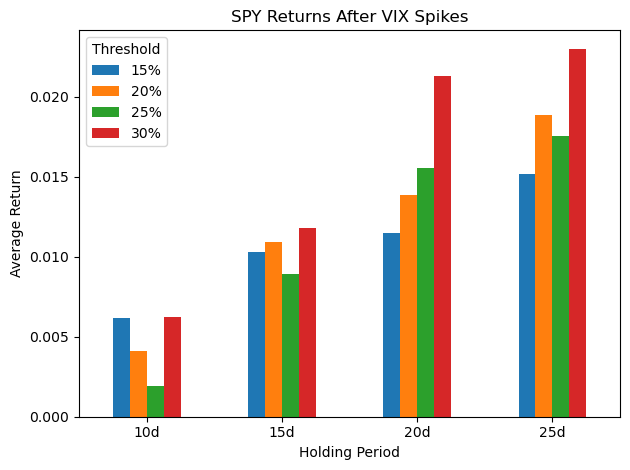

In [91]:
plt.figure()

spy_pivot.plot(kind="bar")
plt.title("SPY Returns After VIX Spikes")
plt.ylabel("Average Return")
plt.xlabel("Holding Period")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

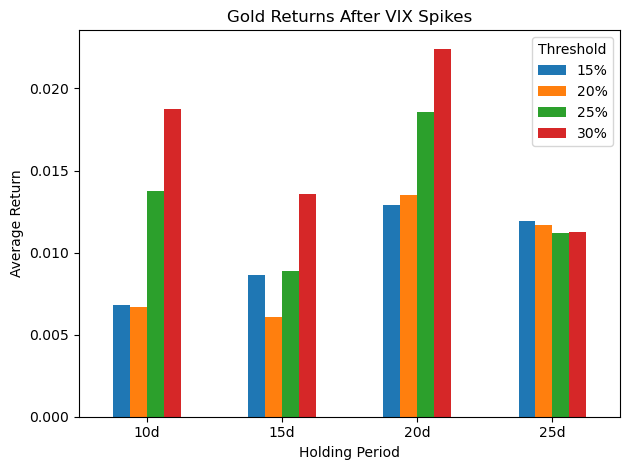

In [92]:
plt.figure()

gold_pivot.plot(kind="bar")
plt.title("Gold Returns After VIX Spikes")
plt.ylabel("Average Return")
plt.xlabel("Holding Period")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

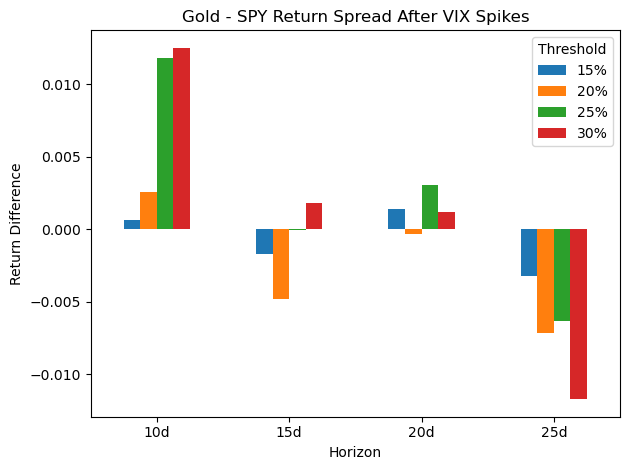

In [93]:
spread_pivot = gold_pivot - spy_pivot

plt.figure()
spread_pivot.plot(kind="bar")
plt.title("Gold - SPY Return Spread After VIX Spikes")
plt.ylabel("Return Difference")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()